# Resource estimation for an L × L Hubbard lattice

Adapted from the Heisenberg resource-estimation notebook: standard ten-bit QPE, identity state preparation, repeated powers, and the same Majorana resource-estimation sweep. The Hubbard Hamiltonian and second-order plaquette builder follow [PR 707's benchmark](https://github.com/microsoft/qdk-chemistry/pull/707/changes#diff-3d2f7746b4bc12c1cc11aa64fe7f77ed1d8bcc35e388caa575f00b7e475c22a1).

Use the existing **PR 728 virtual environment** as the notebook kernel; it now includes the plaquette support from PR 707. The default side length matches the Heisenberg notebook's current `n = 100`; choose an even `n >= 4`.

The model has periodic boundaries, hopping $t=1$, onsite interaction $U=8t$, and zero onsite one-body energy. The energy target is $\epsilon=0.0051L^2$, with longest evolution $T_{\max}=1/\epsilon$. Unlike the script, this notebook keeps standard QPE with ten bits and identity preparation; it does not use the script's adaptive bit count, single IQPE iteration, or filling-dependent reference determinant.

The full notebook was validated at `n=4` in the PR 728 environment. The default `n=100` estimate has not been run.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from qdk.qre import PSSPC, EstimationTable, LatticeSurgery, estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux
from qdk_chemistry.algorithms import create
from qdk_chemistry.algorithms.state_preparation import identity_state_prep
from qdk_chemistry.data import AlgorithmRef, Circuit, LatticeGraph, MajoranaMapping, QubitOperator
from qdk_chemistry.utils import Logger
from qdk_chemistry.utils.model_hamiltonians import create_hubbard_hamiltonian

Logger.set_global_level(Logger.LogLevel.off)

## Build the periodic lattice and Hubbard Hamiltonian

Jordan–Wigner encoding uses $2L^2$ system qubits, with all spin-up modes followed by all spin-down modes. The Hamiltonian argument `epsilon=0.0` is the onsite one-body energy, not the energy-precision target.

In [ ]:
HOPPING_T = 1.0
U_OVER_T = 8.0


def create_lattice(n: int) -> LatticeGraph:
    """Build the periodic square lattice used by the Hubbard benchmark."""
    if n < 4 or n % 2:
        raise ValueError("Choose an even lattice side length of at least 4.")
    return LatticeGraph.square(n, n, periodic_x=True, periodic_y=True)


def create_hamiltonian(graph: LatticeGraph) -> QubitOperator:
    """Map the uniform repulsive Hubbard model to spin-blocked Jordan-Wigner qubits."""
    fermionic_hamiltonian = create_hubbard_hamiltonian(graph, epsilon=0.0, t=HOPPING_T, U=U_OVER_T * HOPPING_T)
    return create("qubit_mapper").run(fermionic_hamiltonian, mapping=MajoranaMapping.jordan_wigner(2 * graph.num_sites))


n = 100
graph = create_lattice(n)
hamiltonian = create_hamiltonian(graph)

print(f"Lattice: {n} x {n} (periodic)")
print(f"Sites: {graph.num_sites}")
print(f"Nearest-neighbor bonds: {graph.num_edges}")
print(f"Hamiltonian qubits: {hamiltonian.num_qubits}")
print(f"Pauli terms: {len(hamiltonian.pauli_strings)}")

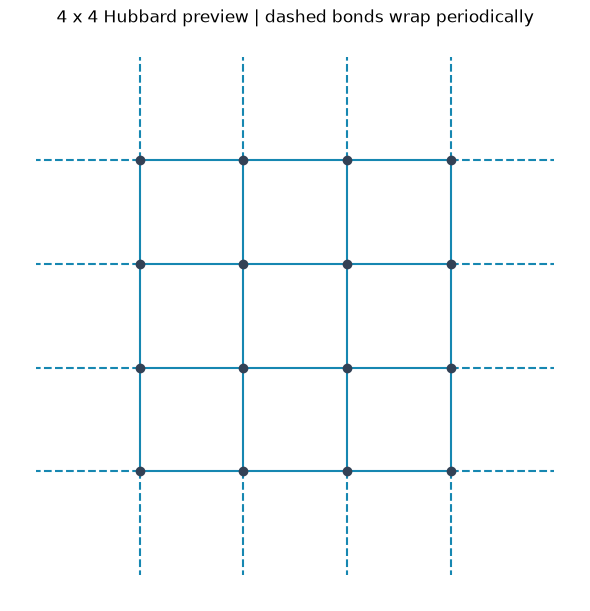

In [4]:
# A separate small preview; graph, hamiltonian, and n are unchanged.
plot_n = 4
plot_graph = create_lattice(plot_n)
positions = np.array([(site % plot_n, site // plot_n) for site in range(plot_graph.num_sites)])
adjacency = plot_graph.sparse_adjacency_matrix().tocoo()
lattice_fig, lattice_ax = plt.subplots(figsize=(6, 6), layout="constrained")
for site_i, site_j in zip(adjacency.row, adjacency.col, strict=True):
    if site_i >= site_j:
        continue
    start, end = positions[[site_i, site_j]]
    displacement = end - start
    if np.max(np.abs(displacement)) > 1:
        displacement = (displacement + plot_n // 2) % plot_n - plot_n // 2
        for origin, target in ((start, start + displacement), (end, end - displacement)):
            lattice_ax.plot(*np.array([origin, target]).T, color="#1687B1", linestyle="--")
    else:
        lattice_ax.plot(*np.array([start, end]).T, color="#1687B1")
lattice_ax.scatter(*positions.T, color="#334155", zorder=3)
lattice_ax.set_aspect("equal")
lattice_ax.set_axis_off()
lattice_ax.set_title(f"{plot_n} x {plot_n} Hubbard preview | dashed bonds wrap periodically")
plt.show()

## Standard quantum phase estimation

As in the Heisenberg notebook's circuit, standard QPE uses ten phase qubits, controlled powers $U^{2^k}$ for $k=0,\ldots,9$, the inverse quantum Fourier transform, and phase-register measurements. The circuit contains the entire power ladder, not just its longest iteration.

### Second-order plaquette evolution

The `"plaquette"` Hamiltonian unitary builder uses Campbell's second-order splitting into onsite interactions and two hopping-plaquette tilings. Each individual plaquette hopping evolution is exact; the product formula approximates evolution under their sum.

Use the script's `"pauli_sequence"` controlled mapper, which supports the builder's conjugated blocks and Hamming-weight phasing batches. The Heisenberg notebook's `"batched_pauli_sequence"` mapper is for flat Pauli sequences and cannot lower these structured terms.

The manual division rule and `dt=0.1` placeholder are retained from Heisenberg. Automatic division sizing is disabled here; this is not the script's `target_accuracy` schedule.

In [ ]:
# Calibrate the Trotter step at the largest QPE power, not at the base time.
TARGET_PRECISION = 0.0051 * n**2
M_PRECISION = 10
MAX_QPE_EXPONENT = M_PRECISION - 1
MAX_QPE_POWER = 2**MAX_QPE_EXPONENT
longest_time = 1 / TARGET_PRECISION

# The unitary builder receives the BASE time; QPE repeats its powers.
total_time = longest_time / MAX_QPE_POWER
dt = 0.1  # Construction placeholder: requires calibration at longest_time.

print(f"Energy precision: {TARGET_PRECISION:.10g}")
print(f"Longest evolution: {longest_time:.10g}")
print(f"Base evolution: {total_time:.10g}; bits: {M_PRECISION}; maximum power: {MAX_QPE_POWER}")

With $\epsilon=0.0051L^2$, set $T_{\max}=1/\epsilon$ and $t_0=T_{\max}/512$. For $r_0=\max(1,\lceil t_0/\mathrm{dt}\rceil)$ base divisions, every power uses the same actual step $\delta=t_0/r_0$. The longest power executes $512r_0$ steps and the entire ladder executes $1023r_0$ steps.

Calibrate $\|S_2(\delta)^{512r_0}\psi_0-e^{-iE_0T_{\max}}\psi_0\|_2<0.01$ against an exact ground state; the current step is a construction placeholder, not a validated approximation. Keep `power_strategy="repeat"` rather than rescaling the step at each power.

Identity state preparation is also a resource-counting placeholder, not Hubbard ground-state preparation. These estimates do not include state-preparation or overlap-amplification costs, nor certify full-QPE energy accuracy or failure probability.

In [ ]:
num_steps = max(1, int(np.ceil(total_time / dt)))

unitary_builder = AlgorithmRef(
    "hamiltonian_unitary_builder",
    "plaquette",
    time=total_time,
    order=2,
    num_divisions=num_steps,
    target_accuracy=0.0,
    lattice_width=n,
    lattice_height=n,
    power_strategy="repeat",
)
circuit_mapper = AlgorithmRef("controlled_circuit_mapper", "pauli_sequence")

# The standard QPE builder returns a single-element list of circuits.
circuit_builder = create(
    "qpe_circuit_builder",
    "qdk_standard",
    num_bits=M_PRECISION,
    unitary_builder=unitary_builder,
    controlled_circuit_mapper=circuit_mapper,
)
qpe_circuits = circuit_builder.run(
    state_preparation=identity_state_prep(num_qubits=hamiltonian.num_qubits),
    qubit_hamiltonian=hamiltonian,
)
print(f"Base divisions: {num_steps}; actual step: {total_time / num_steps:.10g}")
print(f"Longest-power steps: {MAX_QPE_POWER * num_steps}; full-QPE steps: {(2**M_PRECISION - 1) * num_steps}")

## Estimate fault-tolerant resources

The Majorana error rate, synthesis sweep, lattice-surgery slowdown sweep, distillation-factory model, and estimator error budget are unchanged from Heisenberg.

In [ ]:
MAJORANA_ERROR_RATE = 1e-5
ARCHITECTURE = Majorana(error_rate=MAJORANA_ERROR_RATE)
MAX_ERROR = 0.01


def estimate_physical(circuit: Circuit, name: str) -> EstimationTable:
    """Return the qubit/runtime Pareto frontier on the Majorana architecture."""
    application = circuit.get_qre_application()
    trace_query = (
        application.q()
        * PSSPC.q(num_ts_per_rotation=list(range(20, 45, 2)))
        * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 20)])
    )
    isa_query = ThreeAux.q() * RoundBasedFactory.q(code_query=ThreeAux.q())
    return estimate(application, ARCHITECTURE, isa_query, trace_query, max_error=MAX_ERROR, name=name)


estimates = estimate_physical(qpe_circuits[0], f"{n}x{n} Hubbard lattice")
print(estimates)

In [ ]:
# Break total qubits into compute, factory, and memory components.
estimates.add_qubit_partition_column()
estimates.add_factory_summary_column()

estimates.as_frame()

In [ ]:
fig = plot_estimates(
    [estimates],
    runtime_unit="months",
    figsize=(15, 7),
    scatter_args={"marker": "x", "s": 120, "linewidths": 2.5},
)
ax = fig.axes[0]
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.set_ylabel(ax.get_ylabel(), fontsize=30)
ax.tick_params(axis="both", labelsize=26)
ax.legend(fontsize=26, loc="upper right")
fig.set_layout_engine("constrained")
fig